# Parcial Deep Learning - Punto 2
**Identificación de Lengua de Señas**

Este notebook aborda el segundo punto del parcial:
*Crear una red neuronal densa que identifique lengua de señas usando el dataset de: 27-class-sign-language-dataset*

## Pasos:
1. Descarga del dataset
2. Preprocesamiento (Flattening de las imágenes para la red densa, normalización)
3. Definición del modelo Dense (MLP) con Keras
4. Entrenamiento con EarlyStopping
5. Análisis de los resultados (Loss/Accuracy, Matriz de Confusión)


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import cv2

os.environ["KERAS_BACKEND"] = "torch"
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("Keras version:", keras.__version__)

Keras version: 3.15.1


## 1. Descarga del Dataset
Usaremos `kagglehub` para descargar el dataset directamente. El dataset público contiene directamente los archivos de datos en matrices numpy.

In [2]:
# Descargar el dataset (no requiere autenticación para este dataset público)
path = kagglehub.dataset_download("ardamavi/27-class-sign-language-dataset")
print("Ruta del dataset:", path)

# Cargar las matrices numpy
X_raw = np.load(os.path.join(path, "X.npy"))
y_raw = np.load(os.path.join(path, "Y.npy"))

print("Shape inicial de X:", X_raw.shape)
print("Shape inicial de y:", y_raw.shape)

# Hay 27 clases en total, pero para mapearlos a nombres de clases:
# Basado en la descripción, son letras del abecedario.
clases = [str(i) for i in range(27)]


Ruta del dataset: C:\Users\Jorgesinho\.cache\kagglehub\datasets\ardamavi\27-class-sign-language-dataset\versions\1


Shape inicial de X: (22801, 128, 128, 3)
Shape inicial de y: (22801, 1)


## 2. Preprocesamiento de los Datos
Para una **Red Neuronal Densa (MLP)**, la entrada debe ser un vector 1D. El dataset original tiene imágenes a color de 128x128.
Para reducir la carga computacional de la red densa y evitar problemas de memoria, las convertiremos a escala de grises y las redimensionaremos a 64x64 antes de aplanarlas.

In [3]:
from sklearn.preprocessing import LabelEncoder
IMG_SIZE = 64

X_processed = []

for i in range(len(X_raw)):
    # Convertir a escala de grises
    img_gray = cv2.cvtColor(X_raw[i], cv2.COLOR_RGB2GRAY)
    # Redimensionar a 64x64
    img_resized = cv2.resize(img_gray, (IMG_SIZE, IMG_SIZE))
    X_processed.append(img_resized.flatten())

X = np.array(X_processed, dtype='float32') / 255.0  # Normalización

le = LabelEncoder()
y = le.fit_transform(y_raw.flatten())
clases = le.classes_

print("Forma de X tras preprocesamiento:", X.shape)
print("Forma de y:", y.shape)

# Dividir en Train (70%), Val (15%) y Test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Val: {X_val.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Forma de X tras preprocesamiento: (22801, 4096)
Forma de y: (22801,)


Train: 15959 muestras
Val: 3421 muestras
Test: 3421 muestras


## 3. Definición del Modelo (Red Neuronal Densa)
Crearemos una arquitectura MLP pura (capas Dense).

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input, BatchNormalization
from keras.optimizers import Adam

num_classes = len(np.unique(y))
input_dim = X_train.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(num_classes, activation='softmax')
])

model.summary()

# Compilar modelo
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,895,515 (18.67 MB)

 Trainable params: 4,891,675 (18.66 MB)

 Non-trainable params: 3,840 (15.00 KB)

## 4. Entrenamiento
Utilizaremos `EarlyStopping` para detener el entrenamiento cuando el modelo deje de mejorar en el conjunto de validación.

In [5]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=128,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/100


  1/125 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.0391 - loss: 4.3793

  2/125 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.0352 - loss: 4.3365  

  3/125 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.0365 - loss: 4.3432

  4/125 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.0352 - loss: 4.2956

...

121/125 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5700 - loss: 1.3687

122/125 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5697 - loss: 1.3702

123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5695 - loss: 1.3702

124/125 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5698 - loss: 1.3703

125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.5697 - loss: 1.3703 - val_accuracy: 0.4832 - val_loss: 1.8230 - learning_rate: 1.5625e-05


## 5. Análisis de Resultados (Evaluación)
Evaluaremos el rendimiento en el conjunto de prueba.

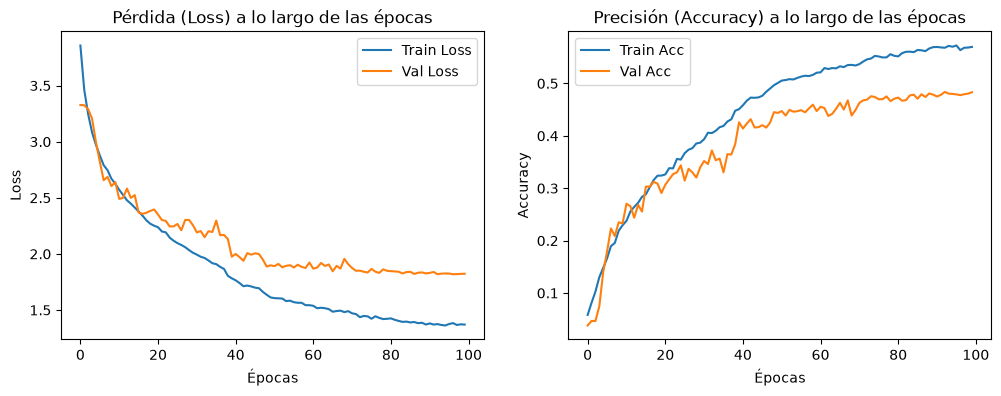

In [6]:
# Gráficas de Loss y Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['loss'], label='Train Loss')
ax1.plot(history.history['val_loss'], label='Val Loss')
ax1.set_title('Pérdida (Loss) a lo largo de las épocas')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc')
ax2.plot(history.history['val_accuracy'], label='Val Acc')
ax2.set_title('Precisión (Accuracy) a lo largo de las épocas')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()

  1/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4375 - loss: 2.2167

  6/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5104 - loss: 1.7583

 11/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4943 - loss: 1.8107

 17/107 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4945 - loss: 1.8379

 23/107 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4959 - loss: 1.8377

...

 89/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


              precision    recall  f1-score   support

           0       0.48      0.42      0.45       130
           1       0.48      0.44      0.46       129
           2       0.36      0.29      0.32       130
           3       0.47      0.43      0.45       130
           4       0.24      0.23      0.24       129
           5       0.37      0.42      0.39       130
           6       0.28      0.37      0.32       130
           7       0.36      0.32      0.34       130
           8       0.38      0.49      0.43       130
           9       0.36      0.38      0.37       130
          10       0.12      0.04      0.06        47
          11       0.44      0.46      0.45       129
          12       0.51      0.47      0.49       130
          13       0.57      0.58      0.58       129
          14       0.62      0.55      0.58       130
          15       0.61      0.62      0.62       130
          16       0.35      0.34      0.34       129
          17       0.60    

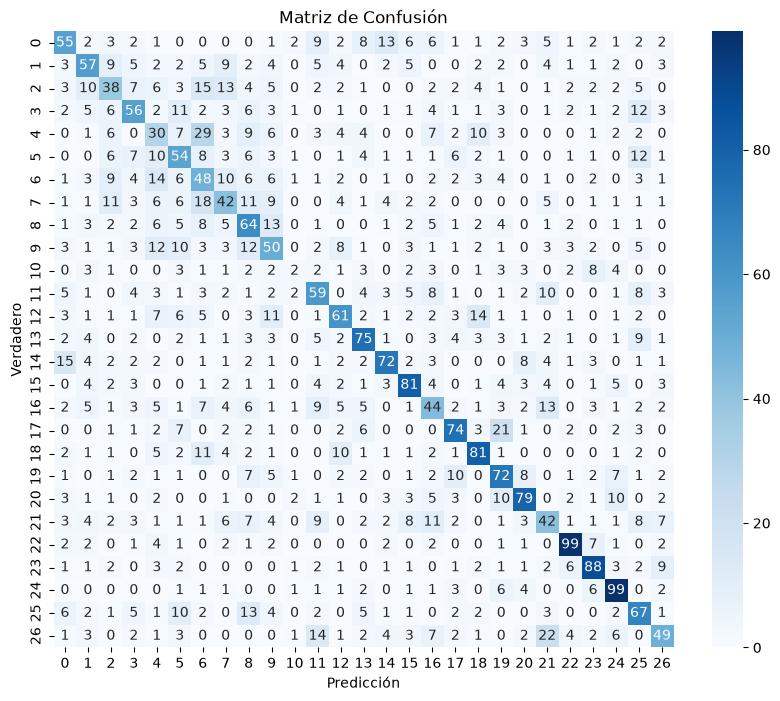

Modelo guardado como 'modelo_punto2.keras'


In [7]:
# Predicciones
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Reporte de clasificación
print(classification_report(y_test, y_pred))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión')
plt.show()

# Guardar el modelo entrenado para uso posterior (ej. inferencia en tiempo real)
model.save('modelo_punto2.keras')
print("Modelo guardado como 'modelo_punto2.keras'")

## 6. Conclusiones
De acuerdo a lo esperado según el libro guía (hasta el cap. 22):
1. **Pérdida de información espacial**: Al aplanar la imagen a un vector 1D, el modelo pierde el contexto espacial (relación entre píxeles vecinos), lo que dificulta reconocer características geométricas complejas de las manos.
2. **Número de parámetros masivo**: El número de pesos en la primera capa oculta es enorme, lo que aumenta el riesgo de sobreajuste y requiere más memoria computacional frente a redes especializadas como las convolucionales (CNNs).
3. **Desempeño general**: A pesar de estas limitaciones arquitectónicas para procesamiento de imágenes, la red densa (MLP) logra encontrar patrones generales funcionando como un aproximador universal, aunque con una precisión probablemente inferior a la que se obtendría con una CNN.